In [ ]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from dotenv import load_dotenv
load_dotenv()
news_api_key = os.getenv("NEWS_API_KEY")
fred_api_key = os.getenv("FRED_API_KEY")

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from newsapi import NewsApiClient

from fredapi import Fred

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

from catboost import CatBoostClassifier

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(model_name)

newsapi = NewsApiClient(api_key=news_api_key)

fred = Fred(api_key=fred_api_key)

news_path = os.path.join('C:/Users/happy/.cache/kagglehub/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests/versions/2',
                         'raw_analyst_ratings.csv') #path = kagglehub.dataset_download("miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests")

def get_sentiment_score(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    outputs = sentiment_model(**inputs)
    prediction = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    probs = prediction.detach().numpy()[0]
    sentiment_score = probs[0] - probs[1]

    return sentiment_score

c:\Users\happy\Desktop\STUFF\KhPI\Semester_8\Thesis\Stock-Market-Forecasting-Component\hf-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15378.04it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
ticker, macro, start_date, end_date = "AAPL", "FEDFUNDS", "2018-01-01", "2020-12-31"

In [3]:
def get_technical(ticker, start_date, end_date):
    df = yf.download(ticker, start=start_date, end=end_date)

    df.dropna(inplace=True)
    df = df.xs(ticker, axis=1, level=1)
    
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()

    return df

def get_macro(macro, start_date, end_date):
    return fred.get_series(macro, start_date, end_date).to_frame(name=macro)

def merge_macro(df, macro):
    df = df.merge(macro, left_index=True, right_index=True, how='left')
    return df

def get_sentiment_kaggle(ticker, start_date, end_date):
    kaggle_df = pd.read_csv(news_path, encoding="latin1", index_col=0)
    kaggle_df.drop(columns=['url','publisher'],inplace=True)

    kaggle_df = kaggle_df[kaggle_df['stock'] == ticker].copy()

    kaggle_df['date'] = kaggle_df['date'].astype(str).str.strip()
    kaggle_df['date'] = pd.to_datetime(kaggle_df['date'], errors='coerce', format="%Y-%m-%d %H:%M:%S", utc=True)

    kaggle_df['date'] = pd.to_datetime(kaggle_df['date'], errors='coerce', utc=True)
    kaggle_df['date'] = kaggle_df['date'].dt.tz_localize(None)
    kaggle_df['date'] = kaggle_df['date'].dt.normalize()
    kaggle_df = kaggle_df[kaggle_df['date'].between(start_date, end_date)].copy()

    kaggle_df = kaggle_df.rename(columns={'headline': 'title'})

    kaggle_df['sentiment'] = kaggle_df['title'].apply(lambda x: get_sentiment_score(x))
    kaggle_df['sentiment'] = pd.to_numeric(kaggle_df['sentiment'], errors='coerce')

    return kaggle_df

def get_sentiment_newsapi(q):
    newsapi_df = pd.DataFrame(newsapi.get_everything(q=q, language='en', sort_by='relevancy')['articles'])

    newsapi_df['date'] = pd.to_datetime(newsapi_df['publishedAt']).dt.date
    newsapi_df['sentiment'] = newsapi_df['title'].apply(lambda x: get_sentiment_score(x))
    newsapi_df['sentiment'] = pd.to_numeric(newsapi_df['sentiment'], errors='coerce')

    return newsapi_df

def aggregate_daily_sentiment(news_df):
    daily = news_df.groupby(news_df['date'].dt.date).agg({
        'sentiment': ['mean', 'min', 'max', 'std', 'count']})
    
    daily.columns = ['_'.join(col).strip() for col in daily.columns.values]
    daily['sentiment_std'] = daily['sentiment_std'].fillna(0)
    
    return daily

def merge_sentiment(df, daily_sentiment_df):
    df = df.merge(daily_sentiment_df, left_index=True, right_index=True, how='left')
    return df

In [4]:
def get_master_df(ticker, macro, start_date, end_date):
    master_df = get_technical(ticker, start_date, end_date)

    fed_data = get_macro(macro, start_date, end_date)
    master_df = merge_macro(master_df, fed_data)

    master_df = master_df.rename(columns={macro: 'macro'})

    raw_news = get_sentiment_kaggle(ticker, start_date, end_date)
    daily_mood = aggregate_daily_sentiment(raw_news)
    master_df = merge_sentiment(master_df, daily_mood)

    last_news_date = daily_mood.index.max()
    master_df = master_df.loc[:last_news_date]

    master_df.ffill(inplace=True)
    master_df.dropna(inplace=True)

    return master_df

def get_no_sentiment_master_df(ticker, macro, start_date, end_date):
    master_df = get_technical(ticker, start_date, end_date)

    fed_data = get_macro(macro, start_date, end_date)
    master_df = merge_macro(master_df, fed_data)

    master_df = master_df.rename(columns={macro: 'macro'})

    master_df.ffill(inplace=True)
    master_df.dropna(inplace=True)

    return master_df

In [ ]:
no_sentiment_df = get_no_sentiment_master_df(ticker, macro, "2000-01-01", "2026-01-01")

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,SMA_20,SMA_50,macro
Date,,,,,,,,
2000-03-14,0.855818,0.930726,0.853945,0.908019,428579200,0.890352,0.829135,5.85
2000-03-15,0.870800,0.900763,0.854882,0.866118,443609600,0.889322,0.829781,5.85
2000-03-16,0.910594,0.913872,0.857691,0.878759,378100800,0.892108,0.832637,5.85
2000-03-17,0.936344,0.936344,0.896081,0.899827,305043200,0.895900,0.835783,5.85
2000-03-20,0.921362,0.945707,0.916681,0.925108,204489600,0.900301,0.839978,5.85
...,...,...,...,...,...,...,...,...
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600,276.892905,270.701263,3.72
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800,276.685599,271.186837,3.72
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200,276.431337,271.717334,3.72


[*********************100%***********************]  1 of 1 completed
C:\Users\happy\AppData\Local\Temp\ipykernel_25164\3780919588.py:14: Pandas4Warning: Slicing with a datetime.date object is deprecated. Explicitly cast to Timestamp instead.
  master_df = master_df.loc[:last_news_date]


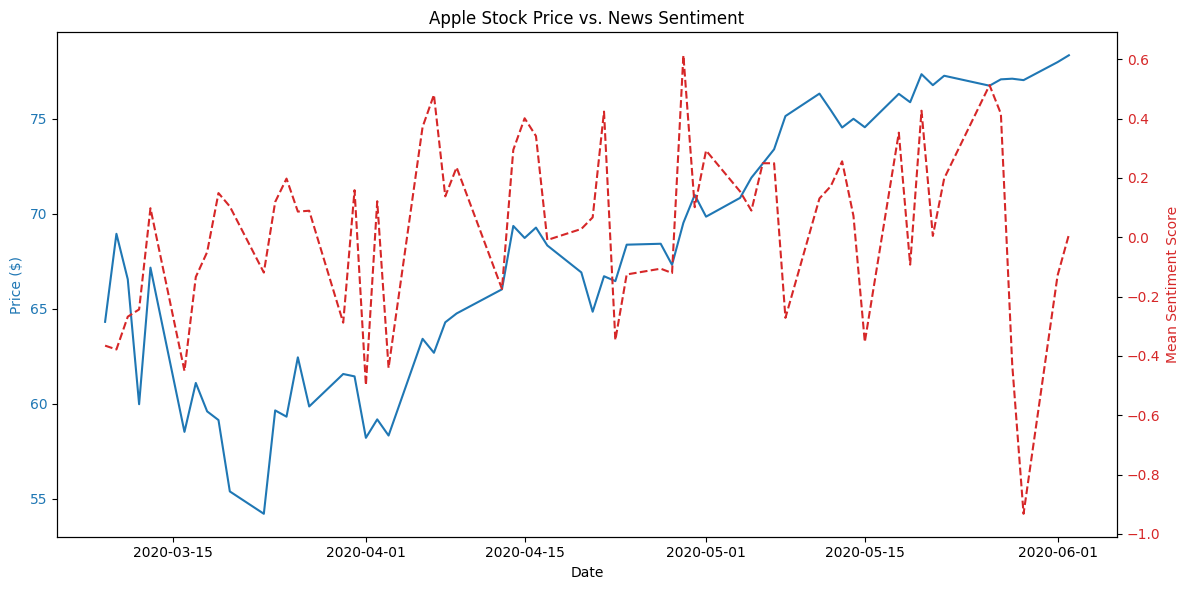

In [6]:
master_df = get_master_df(ticker, macro, start_date, end_date)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)', color='tab:blue')
ax1.plot(master_df.index, master_df['Close'], color='tab:blue', label='AAPL Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Mean Sentiment Score', color='tab:red')
ax2.plot(master_df.index, master_df['sentiment_mean'], color='tab:red', linestyle='--', label='Sentiment')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Apple Stock Price vs. News Sentiment')
fig.tight_layout()
plt.show()

In [52]:
def prepare_data(threshold):
    df = no_sentiment_df[['Open','High','Low','Close','Volume','macro','SMA_20','SMA_50']].copy()

    df['volatility_10'] = df['Close'].rolling(10).std()
    df['momentum_5'] = df['Close'].pct_change(5)

    df['return'] = df['Close'].pct_change().shift(-1)
    df['target'] = (df['return'] > threshold).astype(int)

    df = df.dropna()

    X = df.drop(columns=['target', 'return'])
    y = df['target']

    return train_test_split(X, y, test_size=0.2, shuffle=False), X.columns

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    baseline = (y_test == y_test.mode()[0]).mean()

    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    f1_1 = report['1']['f1-score']

    pred_rate = np.mean(preds)

    return acc, baseline, precision_1, recall_1, f1_1, pred_rate

In [ ]:
def run_experiments(thresholds):
    results = []
    for t in thresholds:
        (X_train, X_test, y_train, y_test), cols = prepare_data(t)
        scale = (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1

        models = {
            "LogReg": LogisticRegression(max_iter=1000),
            "RF": RandomForestClassifier(class_weight='balanced', random_state=42),
            "ET": ExtraTreesClassifier(class_weight='balanced', random_state=42),
            "XGB": xgb.XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                scale_pos_weight=scale, random_state=42),
            "LGBM": lgb.LGBMClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                class_weight='balanced', random_state=42),
            "CB": CatBoostClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1, scale_pos_weight=scale,
                random_state=42, verbose=0, allow_writing_files=False)}

        for name, model in models.items():
            acc, base, p, r, f1, pr = evaluate_model(model, X_train, X_test, y_train, y_test)
            results.append({
                "model": name, "threshold": t,
                "accuracy": acc, "baseline": base,
                "precision_1": p, "recall_1": r, "f1_1": f1,
                "predicted_1_rate": pr})

    return pd.DataFrame(results)
    

In [90]:
from sklearn.metrics import r2_score

reg_df = no_sentiment_df[['Open','High','Low','Close','Volume','macro','SMA_20','SMA_50']].copy()

reg_df['volatility_10'] = reg_df['Close'].rolling(10).std()
reg_df['momentum_5'] = reg_df['Close'].pct_change(5)

reg_df = reg_df.dropna()

reg_df['Target'] = reg_df['Close'].pct_change().shift(-1)
reg_df.dropna(inplace=True)

y = reg_df['Target']
X = reg_df.drop(columns=['Target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

xgb_regressor = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_regressor.fit(X_train, y_train)
preds = xgb_regressor.predict(X_test)

print(r2_score(y_test, preds))

reg_df = reg_df.iloc[-len(X_test):].copy()
reg_df['Shift'] = preds
reg_df['Predicted'] = reg_df['Close'] + reg_df['Shift']
reg_df['Target'] = reg_df['Close'].pct_change().shift(-1)

print("MSE:", mean_squared_error(y_test, preds))
reg_df

-1.1279362553965537
MSE: 0.0006569141387387107


,Open,High,Low,Close,Volume,macro,SMA_20,SMA_50,volatility_10,momentum_5,Target,Shift,Predicted
Date,,,,,,,,,,,,,
2020-11-02,105.931318,107.455579,104.193465,105.601219,122866900,0.09,112.792934,113.466280,3.167945,-0.054585,0.015354,0.005870,105.607089
2020-11-03,106.465305,108.241986,105.562398,107.222580,107624400,0.09,112.660895,113.166913,3.113364,-0.052830,0.040837,0.005870,107.228450
2020-11-04,110.814796,112.222551,109.076943,111.601196,138235500,0.09,112.654585,112.975166,2.939552,0.033723,0.035494,0.003532,111.604728
2020-11-05,114.513794,116.135148,113.465263,115.562332,126387100,0.09,112.851671,112.829682,3.377624,0.032171,-0.001136,-0.007593,115.554739
2020-11-06,115.071210,115.927044,112.941340,115.431053,114457900,0.09,112.945106,112.710940,3.745853,0.092181,-0.019968,-0.011873,115.419180
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,270.586809,272.245261,269.308007,272.105377,29642000,3.72,277.050758,270.176155,2.891168,-0.008193,0.005324,-0.014193,272.091184
2025-12-24,272.085389,275.172497,271.945536,273.554016,17910600,3.72,276.892905,270.701263,2.467490,0.007247,-0.001497,-0.015865,273.538151
2025-12-26,273.903708,275.112569,272.604905,273.144409,21521800,3.72,276.685599,271.186837,2.018952,0.004445,0.001317,-0.015455,273.128954


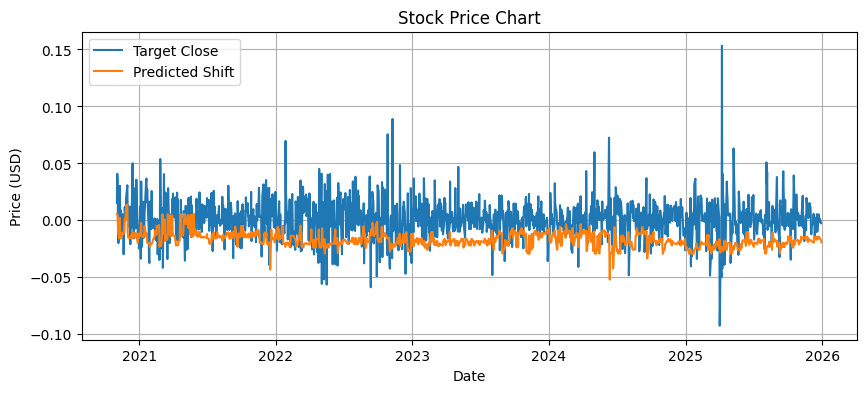

In [91]:
plt.figure(figsize=(10, 4))
plt.plot(reg_df['Target'], label='Target Close')
plt.plot(reg_df['Shift'], label='Predicted Shift')
plt.title('Stock Price Chart')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(loc=2)
plt.grid()
plt.show()

In [ ]:
run_experiments([0.002, 0.003, 0.005, 0.01])

[LightGBM] [Info] Number of positive: 2448, number of negative: 2736
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2391
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,model,threshold,accuracy,baseline,precision_1,recall_1,f1_1,predicted_1_rate
0,LogReg,0.002,0.531636,0.531636,0.000000,0.000000,0.000000,0.000000
1,RF,0.002,0.533179,0.531636,1.000000,0.003295,0.006568,0.001543
2,ET,0.002,0.533179,0.531636,1.000000,0.003295,0.006568,0.001543
3,XGB,0.002,0.534722,0.531636,0.833333,0.008237,0.016313,0.004630
4,LGBM,0.002,0.528549,0.531636,0.461538,0.039539,0.072838,0.040123
5,CB,0.002,0.533951,0.531636,1.000000,0.004942,0.009836,0.002315
6,LogReg,0.003,0.562500,0.562500,0.000000,0.000000,0.000000,0.000000
7,RF,0.003,0.564815,0.562500,1.000000,0.005291,0.010526,0.002315
8,ET,0.003,0.564043,0.562500,1.000000,0.003527,0.007030,0.001543
9,XGB,0.003,0.564815,0.562500,0.636364,0.012346,0.024221,0.008488


[LightGBM] [Info] Number of positive: 1570, number of negative: 3614
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2391
[LightGBM] [Info] Number of data points in the train set: 5184, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

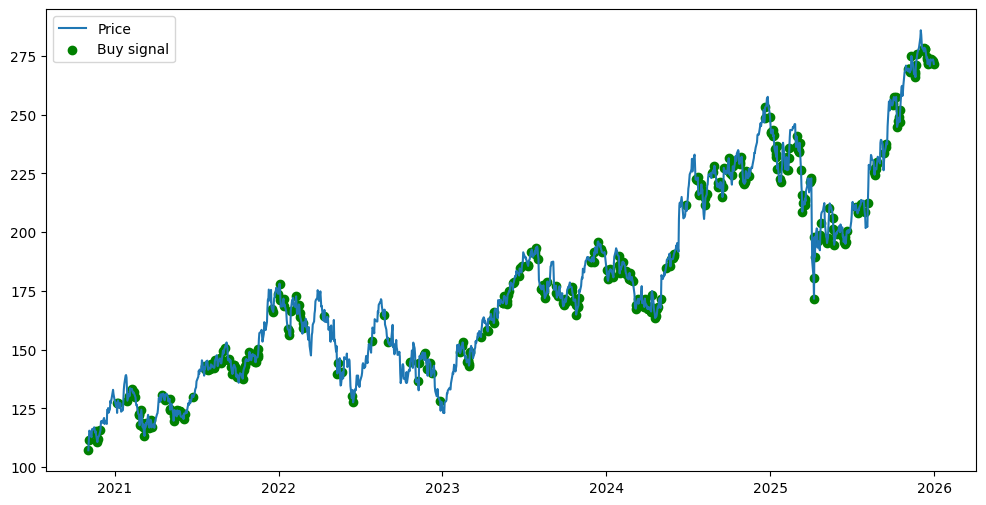

In [62]:
(X_train, X_test, y_train, y_test), cols = prepare_data(0.01)
model_plot = lgb.LGBMClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                class_weight='balanced', random_state=42)
model_plot.fit(X_train, y_train)
preds = model_plot.predict(X_test)

df_plot = no_sentiment_df.copy()

df_plot = df_plot.iloc[-len(y_test):]
df_plot['prediction'] = preds

plt.figure(figsize=(12,6))
plt.plot(df_plot['Close'], label='Price')

buy_signals = df_plot[df_plot['prediction'] == 1]

plt.scatter(buy_signals.index, buy_signals['Close'], color='green', label='Buy signal')

plt.legend()
plt.show()